In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Setup: imports, configurazione, utilities condivise
# ─────────────────────────────────────────────────────────────────────────────
import os
import pickle
import numpy as np
import torch as th
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr, kendalltau
from stable_baselines3 import PPO

import sumo_rl_ego as sre
from human_feedback_rl.common.reward_nets import SumoRewardNet, make_reward_ensemble
from human_feedback_rl.common.env_wrappers import EnvBufferingWrapper

# ── Ambiente ──────────────────────────────────────────────────────────────────
ENV_ID     = "HighwayEgo-v0"
ENV_KWARGS = dict(reward="fast", ego="continuous")
SEED       = 42

EXPERT_MODEL_PATH = (
    "/Users/andreazhang/Documents/fis/sumo-human-feedback-rl/"
    "sumo-rl-ego/sumo_rl_ego/policies/models/ppo-fast/model.zip"
)

# ── Raccolta dati ─────────────────────────────────────────────────────────────
N_EXPERT_STEPS = 100_000
N_RANDOM_STEPS = 100_000

# ── Dataset su disco ──────────────────────────────────────────────────────────
# Di default: stessa directory del notebook. Cambia se necessario.
DATASET_DIR         = Path(os.getcwd())
EXPERT_DATASET_FILE = DATASET_DIR / "expert_trajectories.pkl"
RANDOM_DATASET_FILE = DATASET_DIR / "random_trajectories.pkl"

# ── Reward model ──────────────────────────────────────────────────────────────
# Scegli UNA delle due opzioni (commenta l'altra)
REWARD_MODEL_TYPE = "single"   # "single" | "ensemble"
ENSEMBLE_SIZE     = 3          # usato solo con REWARD_MODEL_TYPE == "ensemble"
NET_ARCH          = [128, 128]
ACTIVATION_FN     = "tanh"

# ── Training ──────────────────────────────────────────────────────────────────
LR           = 1e-3
L2           = 1e-4
N_EPOCHS     = 3000
BATCH_EXPERT = 16   # traiettorie per mini-batch
BATCH_RANDOM = 16

# ─────────────────────────────────────────────────────────────────────────────
# Funzioni di supporto
# ─────────────────────────────────────────────────────────────────────────────

def collect_trajectories(policy_fn, env_id, env_kwargs, n_steps, seed=0):
    """
    Esegue il rollout di `policy_fn(obs) -> actions` per almeno n_steps step.
    Restituisce una lista di Trajectory complete (con i veri reward dell'env).
    """

    import sumo_gym_ego.core.simulation as _sim_mod
    import traci as _traci_mod
    _sim_mod.load_traci = lambda use_gui: _traci_mod

    try:
        venv.close()
    except Exception:
        pass

    venv = sre.make_vec_env(env_id, n_envs=1, base_seed=seed, **env_kwargs)
    buf  = EnvBufferingWrapper(venv)
    obs  = buf.reset()

    collected = 0
    finishing = False
    active    = np.ones(venv.num_envs, dtype=bool)

    while True:
        actions          = policy_fn(obs)
        obs, _, dones, _ = buf.step(actions)
        collected       += venv.num_envs

        if collected >= n_steps:
            finishing = True
        if finishing:
            active &= ~dones
            if not active.any():
                break

    trajectories = buf.pop_finished_trajectories()
    venv.close()
    return trajectories


def traj_return(model, traj):
    """Somma dei reward per step predetti da `model` su una singola traiettoria."""
    obs  = th.tensor(np.array([t.observation for t in traj]), dtype=th.float32)
    acts = th.tensor(np.array([t.action      for t in traj]), dtype=th.float32)
    ns   = th.tensor(np.array([t.next_status for t in traj]), dtype=th.float32)
    done = th.tensor(np.array([float(t.done) for t in traj]), dtype=th.float32)
    return model(obs, acts, ns, done).sum()


print(f"Setup completato.")
print(f"Dataset dir : {DATASET_DIR}")

Setup completato.
Dataset dir : /Users/andreazhang/Documents/fis/sumo-human-feedback-rl/human-feedback-rl/human_feedback_rl/algorithms


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Raccolta dataset offline: traiettorie dell'esperto (PPO-fast)
# Se il file esiste già su disco viene caricato, altrimenti si campiona.
# ─────────────────────────────────────────────────────────────────────────────

# Il modello esperto viene sempre caricato (serve per l'action space nella cella random)
expert_model = PPO.load(EXPERT_MODEL_PATH, device="cpu")

if EXPERT_DATASET_FILE.exists():
    print(f"Dataset esperto trovato — carico da disco: {EXPERT_DATASET_FILE}")
    with open(EXPERT_DATASET_FILE, "rb") as f:
        expert_trajectories = pickle.load(f)
    print(f"  Traiettorie caricate: {len(expert_trajectories)}")
else:
    def expert_policy(obs):
        actions, _ = expert_model.predict(obs, deterministic=True)
        return actions

    print(f"Dataset esperto non trovato — raccolta di {N_EXPERT_STEPS} step …")
    expert_trajectories = collect_trajectories(expert_policy, ENV_ID, ENV_KWARGS, N_EXPERT_STEPS, seed=SEED)

    with open(EXPERT_DATASET_FILE, "wb") as f:
        pickle.dump(expert_trajectories, f)
    print(f"  Salvato in: {EXPERT_DATASET_FILE}")

expert_lengths = [len(t) for t in expert_trajectories]
expert_returns = [t.total_reward() for t in expert_trajectories]
print(f"  Traiettorie  : {len(expert_trajectories)}")
print(f"  Lungh. media : {np.mean(expert_lengths):.1f} step")
print(f"  Return medio : {np.mean(expert_returns):.3f}")
print(f"  Return range : [{min(expert_returns):.3f}, {max(expert_returns):.3f}]")

Dataset esperto non trovato — raccolta di 100000 step …
 Retrying in 1 seconds

Environment closed.
  Salvato in: /Users/andreazhang/Documents/fis/sumo-human-feedback-rl/human-feedback-rl/human_feedback_rl/algorithms/expert_trajectories.pkl
  Traiettorie  : 612
  Lungh. media : 163.4 step
  Return medio : 46.292
  Return range : [-50.556, 74.240]


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Raccolta dataset offline: traiettorie di una policy uniforme (random)
# Se il file esiste già su disco viene caricato, altrimenti si campiona.
# ─────────────────────────────────────────────────────────────────────────────
_action_space = expert_model.action_space

if RANDOM_DATASET_FILE.exists():
    print(f"Dataset random trovato — carico da disco: {RANDOM_DATASET_FILE}")
    with open(RANDOM_DATASET_FILE, "rb") as f:
        random_trajectories = pickle.load(f)
    print(f"  Traiettorie caricate: {len(random_trajectories)}")
else:
    def random_policy(obs):
        n = obs.shape[0]
        return np.array([_action_space.sample() for _ in range(n)])

    print(f"Dataset random non trovato — raccolta di {N_RANDOM_STEPS} step …")
    random_trajectories = collect_trajectories(random_policy, ENV_ID, ENV_KWARGS, N_RANDOM_STEPS, seed=SEED + 1)

    with open(RANDOM_DATASET_FILE, "wb") as f:
        pickle.dump(random_trajectories, f)
    print(f"  Salvato in: {RANDOM_DATASET_FILE}")

random_lengths = [len(t) for t in random_trajectories]
random_returns = [t.total_reward() for t in random_trajectories]
print(f"  Traiettorie  : {len(random_trajectories)}")
print(f"  Lungh. media : {np.mean(random_lengths):.1f} step")
print(f"  Return medio : {np.mean(random_returns):.3f}")
print(f"  Return range : [{min(random_returns):.3f}, {max(random_returns):.3f}]")

print(f"\nDifferenza return medio (esperto − random): "
      f"{np.mean(expert_returns) - np.mean(random_returns):.3f}")

Dataset random non trovato — raccolta di 100000 step …
 Retrying in 1 seconds

Environment closed.
  Salvato in: /Users/andreazhang/Documents/fis/sumo-human-feedback-rl/human-feedback-rl/human_feedback_rl/algorithms/random_trajectories.pkl
  Traiettorie  : 5450
  Lungh. media : 18.3 step
  Return medio : -48.224
  Return range : [-71.488, -20.450]

Differenza return medio (esperto − random): 94.516



Environment closed.
Reward model: single  |  parametri: 20,097
Epoch   20/3000  |  loss=-332.8040  |  r_expert=614.833  |  r_random=69.807
Epoch   40/3000  |  loss=-897.3849  |  r_expert=1331.461  |  r_random=153.531
Epoch   60/3000  |  loss=-1338.8181  |  r_expert=1781.797  |  r_random=170.176
Epoch   80/3000  |  loss=-1713.1316  |  r_expert=2305.671  |  r_random=236.728
Epoch  100/3000  |  loss=-2126.1880  |  r_expert=2901.748  |  r_random=195.063
Epoch  120/3000  |  loss=-2330.2417  |  r_expert=3180.042  |  r_random=240.612
Epoch  140/3000  |  loss=-2078.4917  |  r_expert=3430.554  |  r_random=142.361
Epoch  160/3000  |  loss=-3851.6235  |  r_expert=4457.633  |  r_random=113.331
Epoch  180/3000  |  loss=-3668.8586  |  r_expert=4219.690  |  r_random=184.467
Epoch  200/3000  |  loss=-4102.3701  |  r_expert=4578.902  |  r_random=158.775
Epoch  220/3000  |  loss=-5178.9580  |  r_expert=5890.260  |  r_random=281.349
Epoch  240/3000  |  loss=-5540.8838  |  r_expert=6237.266  |  r_random=

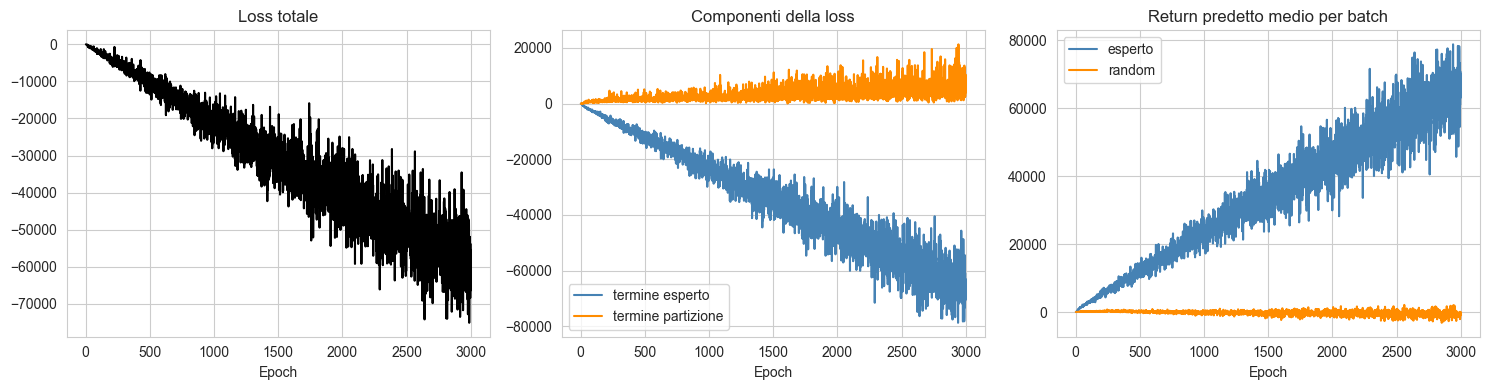

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Training del reward model — loss MaxEnt IRL:
#
#   L(θ) = −(1/N) Σᵢ r̂θ(τᵢᵉˣᵖ)  +  log[ (1/M) Σⱼ exp(r̂θ(τⱼᵘⁿⁱ)) ]
#
# dove r̂θ(τ) = Σₜ rθ(oₜ, aₜ, sₜ₊₁, doneₜ)  (return totale della traiettoria)
#
# Il termine di partizione è calcolato con logsumexp per stabilità numerica:
#   log(1/M Σ exp(r)) = logsumexp(r) − log(M)
# ─────────────────────────────────────────────────────────────────────────────

# ── Istanzia il reward model ──────────────────────────────────────────────────
_venv_tmp = sre.make_vec_env(ENV_ID, n_envs=1, base_seed=0, **ENV_KWARGS)

if REWARD_MODEL_TYPE == "single":
    reward_model = SumoRewardNet(
        _venv_tmp.observation_space,
        _venv_tmp.action_space,
        net_arch=NET_ARCH,
        activation_fn=ACTIVATION_FN,
    )
else:  # ensemble
    reward_model = make_reward_ensemble(
        _venv_tmp,
        n_ensembles=ENSEMBLE_SIZE,
        net_arch=NET_ARCH,
        activation_fn=ACTIVATION_FN,
    )

_venv_tmp.close()
n_params = sum(p.numel() for p in reward_model.parameters())
print(f"Reward model: {REWARD_MODEL_TYPE}  |  parametri: {n_params:,}")

# ── Ciclo di training ─────────────────────────────────────────────────────────
optimizer = th.optim.Adam(reward_model.parameters(), lr=LR, weight_decay=L2)
rng = np.random.default_rng(SEED)

history = {
    "loss": [], "loss_expert": [], "loss_partition": [],
    "mean_expert_return": [], "mean_random_return": [],
}

reward_model.train()
for epoch in range(N_EPOCHS):
    ei = rng.choice(len(expert_trajectories), size=min(BATCH_EXPERT, len(expert_trajectories)), replace=False)
    ri = rng.choice(len(random_trajectories),  size=min(BATCH_RANDOM,  len(random_trajectories)),  replace=False)

    r_expert = th.stack([traj_return(reward_model, expert_trajectories[i]) for i in ei])
    r_random  = th.stack([traj_return(reward_model, random_trajectories[i]) for i in ri])

    N = len(r_expert)
    M = len(r_random)

    loss_expert    = -(1 / N) * r_expert.sum()
    loss_partition =  th.logsumexp(r_random, dim=0) - np.log(M)
    loss = loss_expert + loss_partition

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    history["loss"].append(loss.item())
    history["loss_expert"].append(loss_expert.item())
    history["loss_partition"].append(loss_partition.item())
    history["mean_expert_return"].append(r_expert.mean().item())
    history["mean_random_return"].append(r_random.mean().item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:>4}/{N_EPOCHS}  |  "
              f"loss={loss.item():.4f}  |  "
              f"r_expert={r_expert.mean().item():.3f}  |  "
              f"r_random={r_random.mean().item():.3f}")

# ── Curve di training ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = range(1, N_EPOCHS + 1)

axes[0].plot(epochs, history["loss"], color="black")
axes[0].set_title("Loss totale"); axes[0].set_xlabel("Epoch"); axes[0].grid(True)

axes[1].plot(epochs, history["loss_expert"],    label="termine esperto",    color="steelblue")
axes[1].plot(epochs, history["loss_partition"], label="termine partizione", color="darkorange")
axes[1].set_title("Componenti della loss"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True)

axes[2].plot(epochs, history["mean_expert_return"], label="esperto", color="steelblue")
axes[2].plot(epochs, history["mean_random_return"],  label="random",  color="darkorange")
axes[2].set_title("Return predetto medio per batch"); axes[2].set_xlabel("Epoch")
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()

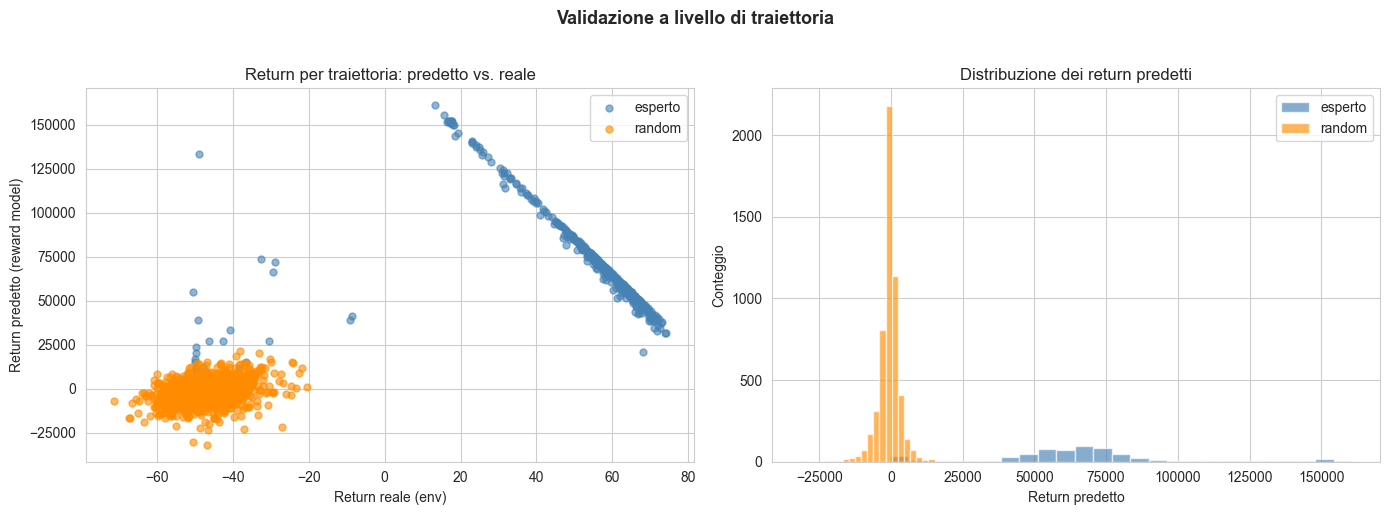

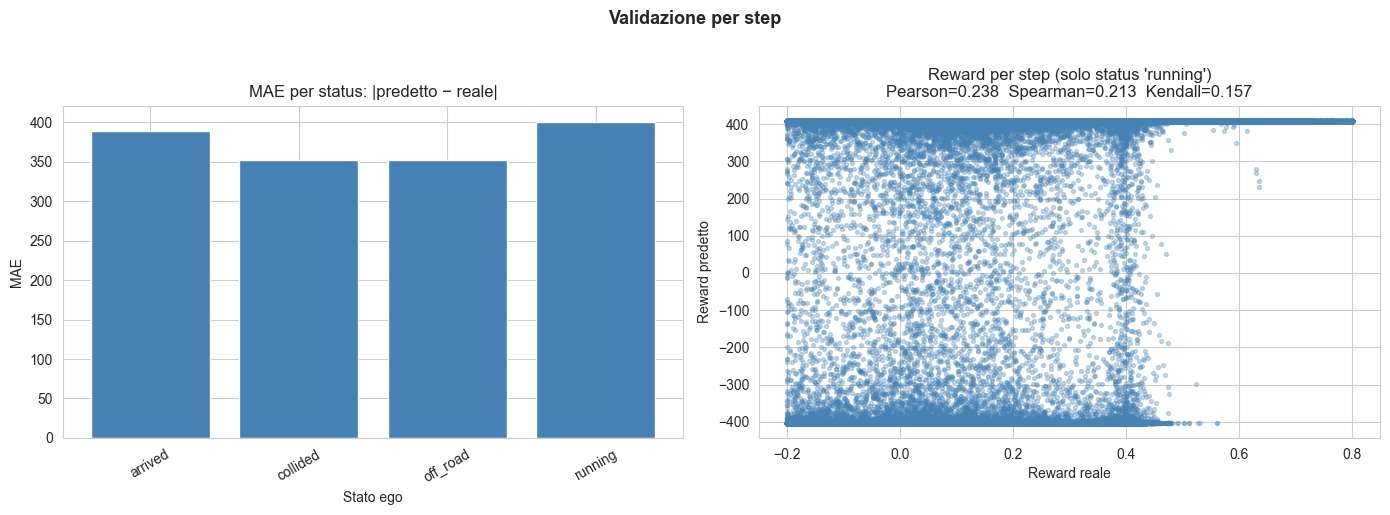

────────────────────────────────────────────────────
Riepilogo validazione
────────────────────────────────────────────────────
  MAE [arrived             ]: 388.3950
  MAE [collided            ]: 352.2612
  MAE [off_road            ]: 351.9926
  MAE [running             ]: 400.8801
  Pearson  (running):          0.2375
  Spearman (running):          0.2133
  Kendall  (running):          0.1566
────────────────────────────────────────────────────
  Gap return predetto (esp−rand): 66753.9872
  ✓ il reward model preferisce le traiettorie esperto


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Grafici per validare quando il reward model approssima bene la reward function
# ─────────────────────────────────────────────────────────────────────────────
STATUS_NAMES = ["arrived", "collided", "off_road", "timeout", "running", "teleported", "removed_unknown"]

reward_model.eval()

# ── Statistiche per traiettoria ───────────────────────────────────────────────
def trajectory_stats(trajectories, model):
    pred, true = [], []
    for traj in trajectories:
        obs  = np.array([t.observation for t in traj], dtype=np.float32)
        acts = np.array([t.action      for t in traj], dtype=np.float32)
        ns   = np.array([t.next_status for t in traj], dtype=np.float32)
        dn   = np.array([float(t.done) for t in traj], dtype=np.float32)
        pred.append(float(model.predict(obs, acts, ns, dn).sum()))
        true.append(traj.total_reward())
    return np.array(pred), np.array(true)

ep, et = trajectory_stats(expert_trajectories, reward_model)
rp, rt = trajectory_stats(random_trajectories,  reward_model)

# ── Statistiche per transizione ───────────────────────────────────────────────
all_trans = [t for traj in expert_trajectories + random_trajectories for t in traj]
obs_all   = np.array([t.observation for t in all_trans], dtype=np.float32)
acts_all  = np.array([t.action      for t in all_trans], dtype=np.float32)
ns_all    = np.array([t.next_status for t in all_trans], dtype=np.float32)
dn_all    = np.array([float(t.done) for t in all_trans], dtype=np.float32)
true_all  = np.array([t.true_reward for t in all_trans], dtype=np.float32)
pred_all  = reward_model.predict(obs_all, acts_all, ns_all, dn_all)

# ── Figura 1: validazione a livello di traiettoria ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(et, ep, alpha=0.6, s=25, label="esperto", color="steelblue")
ax.scatter(rt, rp, alpha=0.6, s=25, label="random",  color="darkorange")
ax.set_xlabel("Return reale (env)")
ax.set_ylabel("Return predetto (reward model)")
ax.set_title("Return per traiettoria: predetto vs. reale")
ax.legend(); ax.grid(True)

ax = axes[1]
ax.hist(ep, bins=25, alpha=0.65, label="esperto", color="steelblue")
ax.hist(rp, bins=25, alpha=0.65, label="random",  color="darkorange")
ax.set_xlabel("Return predetto"); ax.set_ylabel("Conteggio")
ax.set_title("Distribuzione dei return predetti")
ax.legend(); ax.grid(True)

plt.suptitle("Validazione a livello di traiettoria", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

# ── Figura 2: validazione per step per status ─────────────────────────────────
mae_by_status = {}
for i, name in enumerate(STATUS_NAMES):
    mask = ns_all[:, i] == 1
    if mask.sum() > 0:
        mae_by_status[name] = float(np.mean(np.abs(pred_all[mask] - true_all[mask])))

running_mask = ns_all[:, STATUS_NAMES.index("running")] == 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(mae_by_status.keys(), mae_by_status.values(), color="steelblue", edgecolor="white")
ax.set_xlabel("Stato ego"); ax.set_ylabel("MAE")
ax.set_title("MAE per status: |predetto − reale|")
ax.tick_params(axis="x", rotation=30); ax.grid(True, axis="y")

ax = axes[1]
if running_mask.sum() > 1:
    pr, _ = pearsonr(true_all[running_mask],  pred_all[running_mask])
    sr, _ = spearmanr(true_all[running_mask], pred_all[running_mask])
    kr, _ = kendalltau(true_all[running_mask], pred_all[running_mask])
    ax.scatter(true_all[running_mask], pred_all[running_mask], alpha=0.3, s=8, color="steelblue")
    ax.set_xlabel("Reward reale"); ax.set_ylabel("Reward predetto")
    ax.set_title(f"Reward per step (solo status 'running')\n"
                 f"Pearson={pr:.3f}  Spearman={sr:.3f}  Kendall={kr:.3f}")
    ax.grid(True)

plt.suptitle("Validazione per step", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

# ── Riepilogo numerico ────────────────────────────────────────────────────────
print("─" * 52)
print("Riepilogo validazione")
print("─" * 52)
for name, mae in mae_by_status.items():
    print(f"  MAE [{name:<20}]: {mae:.4f}")
if running_mask.sum() > 1:
    print(f"  Pearson  (running):          {pr:.4f}")
    print(f"  Spearman (running):          {sr:.4f}")
    print(f"  Kendall  (running):          {kr:.4f}")
gap = ep.mean() - rp.mean()
print("─" * 52)
print(f"  Gap return predetto (esp−rand): {gap:.4f}")
print(f"  {'✓' if gap > 0 else '✗'} il reward model {'preferisce' if gap > 0 else 'NON preferisce'} le traiettorie esperto")